# La Matrice — Parallel Sheets: geometry vs meaning, with LLM commentary on a chosen traversal

Two parallel graphs over the **same 15 colour nodes**:

```
SHEET A — GEOMETRY : from the BLOCH SPHERE   — k-nearest graph on geodesic distance (how the atoms sit in space)
SHEET B — MEANING  : from la_matrice_words.json — k-nearest graph on meaning similarity (how their meanings relate)
        (same nodes on both planes; vertical couplers join each colour to its own copy)
```

The comparison asks: does **meaning** (Sheet B, your JSON) line up with **geometry** (Sheet A, the
Bloch sphere), or do the two sheets pull apart? That is one rank-correlation number plus the specific
colour pairs where the sheets most disagree.

Your **28 named traversals** are kept as a **reference library of sequences**. They are not a sheet —
they are the vocabulary of moves the LLM can *refer to*: for any transition in a path, the evidence
lists which named sequences contain it, and for any input it lists the named sequences it most
resembles. You pick a **chosen traversal** (or pass **any colour sequence**) and the LLM comments on
it across both sheets, naming the sequences it touches, grounding meaning in `la_matrice_words.json`
and emotion in the semantic-atom classes (Surov Table 2, p. 13).

**Geometry sources.** Surov, *Quantum core affect: color-emotion structure of semantic atom*, Front.
Psychol. 13:838029 (2022) — RGB→qubit atoms (Eqs. 11–15, pp. 10–11), colour↔stage↔emotion (Table 2,
p. 13). Wharton & Koch, *Unit Quaternions and the Bloch Sphere*, arXiv:1411.4999 (2015) — Bloch
vector = pure unit quaternion, SLERP = the rotation `exp(n̂θ/2)` (Eqs. 5–6, p. 6). Multiplex (two-
layer) framing: Kivelä et al., *Multilayer Networks*, J. Complex Netw. 2 (2014).


## 0 · Install

In [1]:
%pip -q install networkx matplotlib scipy sentence-transformers langchain langchain-community
print("ready")

Note: you may need to restart the kernel to use updated packages.
ready


## 1 · Colour layer — the 15 semantic atoms (RGB → Bloch → quaternion), meanings, classes

Same construction as the layering notebook: azimuth φ = Surov process-phase `(hsv_hue + 180) mod 360`;
polar θ = `arccos(2L − 1)`; Bloch vector → pure unit quaternion (Wharton–Koch Eq. 6). Each atom
carries its JSON meaning (`la_matrice_words.json`; sheet `english-words` is the fallback) and its
semantic-atom class (process stage + / − emotion prototypes, Surov Table 2).

In [2]:
import io, json, colorsys, re, numpy as np, pandas as pd

WORDS_JSON = "la_matrice_words.json"   # Sheet B is built from this; sheet english-words used if absent

_CSV = """r,g,b,color,receiver,transmitter,english-words,english-words-code,gnh-indicator,key,sound,circle-angle,direction
170,170,170,grey,cover,lose,respectful effective apposite precary,precary,Economic Wellness,eye contact,synchopation,120,N
250,0,90,pink,category,place,incredibily exquisite ambitious,ambitious,Mental Wellness,make gibberish,tone,260,S
250,200,0,gold,pull,hide,undepartable preflorating technocracy lotiform,technocracy lotiform,Workplace Wellness,define,conductor,135,NE
250,180,120,nude,approach,jump,felicitously deft satisfied unextenuable,unextenuable,Physical Wellness,feel,listen,140,NE
250,110,0,orange,hit,drop,blurry artesian awesome,blurry artesian,Social Wellness,look down,flat/sharp,178,E
255,255,255,white,hope,block,unlavish analeptical,analeptical,Political Wellness,stillness,note,center,center
0,0,255,blue,collect,glean,daintily perfect intelligent photopathy,photopathy,Environmental Wellness,respond,tempo,300,SW
0,255,0,green,transition,grow,bulbous spontaneous heroic,bulbous heroic,Ecological Diversity,composure,staff,67,NW
255,0,0,red,limit,cry,candid apophantic distinct radiant,apophantic,Health,coo,chord,185,E
0,0,0,black,order,scale,undertreated paleoatavistic obeyable swabble,swabble,Good Governance,walk,repeat,290,S
180,50,0,brown,learn,shrink,abundantly notable unique submissive,notable submissive,Education Value,curl up,dischord,150,E
255,255,0,yellow,structure,array,exhilerating redressible authority plausible,redressible authority,Living Standards,speak,largo,130,NE
180,50,255,purple,free,cheer,perfectly great imaginative brave gifted,brave,Cultural Diversity,laugh,cadence,293,S
0,255,255,cyan,act,self,,,Confidence,smile,melody,10,W
255,0,255,magenta,it,matter,,,Aesthetic,show off,harmony,,SE"""

df = pd.read_csv(io.StringIO(_CSV))
for c in ("r","g","b"): df[c] = df[c].astype(int)

def _flatten(d):
    for k,v in d.items():
        if isinstance(v,dict): yield from _flatten(v)
        elif isinstance(v,list): yield k," ".join(map(str,v))
        else: yield k,str(v)
def _json_meaning(color, blob):
    if isinstance(blob,dict) and color in blob:
        v=blob[color]
        if isinstance(v,str): return v
        if isinstance(v,list): return " ".join(map(str,v))
        if isinstance(v,dict): return " ".join(f"{k} {w}" for k,w in _flatten(v))
    if isinstance(blob,list):
        for rec in blob:
            if isinstance(rec,dict) and rec.get("color")==color:
                return " ".join(str(x) for x in rec.values() if isinstance(x,(str,int,float)))
    return ""
_json=None
try:
    with open(WORDS_JSON) as f: _json=json.load(f); print("Sheet B source: merged", WORDS_JSON)
except (FileNotFoundError, json.JSONDecodeError):
    print("Sheet B source: no", WORDS_JSON, "-> using sheet english-words as the meaning input")

def rgb_to_bloch(r,g,b):
    h,s,v = colorsys.rgb_to_hsv(r/255,g/255,b/255)
    L = 0.2126*(r/255)+0.7152*(g/255)+0.0722*(b/255)
    phi = np.radians((h*360+180)%360); z=np.clip(2*L-1,-1,1); th=np.arccos(z)
    return np.array([np.sin(th)*np.cos(phi),np.sin(th)*np.sin(phi),np.cos(th)]),float(np.degrees(th)),float(np.degrees(phi)),float(s)

bloch=[];quats=[];th_l=[];phi_l=[];sat_l=[]
for r,g,b in df[["r","g","b"]].values:
    v,th,ph,s=rgb_to_bloch(r,g,b); bloch.append(v); quats.append(np.array([0.0,*v]))
    th_l.append(round(th,1)); phi_l.append(round(ph,1)); sat_l.append(round(s,3))
bloch=np.array(bloch); quats=np.array(quats)
df["bloch_theta"],df["bloch_phi"],df["saturation"]=th_l,phi_l,sat_l

_STAGE={0:("Perception","calm/serene","depression/shame"),60:("Novelty","surprise/interest","anxiety/fear"),
        120:("Goal-plan","inspiration/ambition","stress/irritation"),180:("Action","passion/bravery/zeal","anger/fury"),
        240:("Progress","acceptance/delight","disappointment/disgust"),300:("Result","joy/contentment","sadness/grief")}
def stage_of(p):
    k=min(_STAGE,key=lambda k:min(abs(p-k),360-abs(p-k))); return _STAGE[k]
df[["stage","emotion_pos","emotion_neg"]]=[stage_of(p) for p in df["bloch_phi"]]

idx={c:i for i,c in enumerate(df["color"])}
hexcol={c:"#%02x%02x%02x"%(df["r"][i],df["g"][i],df["b"][i]) for c,i in idx.items()}
def atom_meaning(i):
    if _json is not None:
        m=_json_meaning(df["color"][i],_json)
        if m: return m,"la_matrice_words.json"
    val=df["english-words"][i]
    ew="" if pd.isna(val) else str(val).strip()
    return (ew or "(none)"),"sheet english-words"

MEANINGS=[(lambda m: "" if m=="(none)" else m)(atom_meaning(i)[0]) for i in range(len(df))]
print(df[["color","bloch_phi","stage","emotion_pos"]].to_string(index=False))

Sheet B source: merged la_matrice_words.json
  color  bloch_phi      stage          emotion_pos
   grey      180.0     Action passion/bravery/zeal
   pink      158.4     Action passion/bravery/zeal
   gold      228.0   Progress   acceptance/delight
   nude      207.7     Action passion/bravery/zeal
 orange      206.4     Action passion/bravery/zeal
  white      180.0     Action passion/bravery/zeal
   blue       60.0    Novelty    surprise/interest
  green      300.0     Result      joy/contentment
    red      180.0     Action passion/bravery/zeal
  black      180.0     Action passion/bravery/zeal
  brown      196.7     Action passion/bravery/zeal
 yellow      240.0   Progress   acceptance/delight
 purple       98.0  Goal-plan inspiration/ambition
   cyan        0.0 Perception          calm/serene
magenta      120.0  Goal-plan inspiration/ambition


## 2 · Reference sequences — your named colour traversals (parsed, for the LLM to cite)

These are **not** a sheet; they are the vocabulary of moves. Parsed robustly: split on commas *and*
spaces (`white red green` → three), normalise typos (`geen → green`, `teal → cyan`), split the
`and knot` row into two sequences, and keep intentional repeats (returns). The evidence later tells
the LLM which of these sequences each transition belongs to, so it can refer to them by name.

In [14]:
PALETTE=set(df["color"])
ALIASES={"geen":"green","teal":"cyan","gray":"grey","violet":"purple"}
def parse_colors(cell):
    out,unknown=[],[]
    for t in re.split(r"[,\s]+", str(cell).strip().lower()):
        if not t: continue
        t=ALIASES.get(t,t)
        (out if t in PALETTE else unknown).append(t)
    return out,unknown

RAW=[
 ("curious to thoughtful","brown, gold, orange, pink"),
 ("angry to soft","red, blue, gold, purple"),
 ("soft to protective","purple, red, orange"),
 ("intelligent to hesitant","red, brown, grey"),
 ("lost to open","green, grey, nude, red, purple"),
 ("joy to new","purple, orange, pink"),
 ("distrust to thoughtful","pink, nude, orange, purple, red"),
 ("happy to resistant","purple, pink, yellow, red"),
 ("productive to messy","grey, brown, nude"),
 ("strict to neutral","black, red, white"),
 ("drain to rise","brown, pink, gold, purple, nude, blue"),
 ("attached to objective","grey, green, black, yellow"),
 ("stuck to escape","orange, red, yellow, purple, orange"),
 ("sad to abundant","white red green, purple, orange"),
 ("cocky to observant","yellow, brown, green"),
 ("it to self","magenta, pink, geen, blue, teal"),
 ("toussaint louverture","black, red, green, blue, green, red"),
 ("knot","white, blue, green, red, black, brown, yellow, purple"),
 ("plot","grey, pink, gold, nude, orange"),
 ("pain","gold, orange"),
 ("practical","yellow, green"),
 ("spiritual","blue, brown"),
 ("prayer","nude, white"),
 ("sad","purple, grey, red"),
 ("precise","pink, black"),
 ("feminine","brown, gold, orange, pink"),
 ("masc","red, blue, orange"),
 ("direct","red, orange"),
]
LIBRARY={}; _flagged={}
for name,raw in RAW:
    rows=[(name,raw)]
    if "and knot" in raw:
        main,knot=raw.split("and knot"); rows=[(name,main),(name+" (knot)",knot)]
    for nm,rw in rows:
        cols,unk=parse_colors(rw); LIBRARY[nm]=cols
        if unk: _flagged[nm]=unk

# transition -> which named sequences contain it (undirected); and colour -> sequences
from collections import defaultdict
TRANS2SEQ=defaultdict(set); COLOR2SEQ=defaultdict(set)
for name,cols in LIBRARY.items():
    for c in cols: COLOR2SEQ[c].add(name)
    for a,b in zip(cols[:-1],cols[1:]):
        if a!=b: TRANS2SEQ[frozenset((a,b))].add(name)
def seqs_for_transition(a,b): return sorted(TRANS2SEQ.get(frozenset((a,b)),[]))
def nearest_sequences(cols, n=3):
    S=set(cols)
    return sorted(((round(len(S&set(v))/len(S|set(v)),2),k) for k,v in LIBRARY.items() if set(v)!=S),
                  reverse=True)[:n]
print(len(LIBRARY),"reference sequences; normalized/unknown:",_flagged or "none")
print("example — transitions using red-purple:",seqs_for_transition("red","purple"))

28 reference sequences; normalized/unknown: none
example — transitions using red-purple: ['distrust to thoughtful', 'lost to open', 'soft to protective']


## 3 · Build the two parallel sheets

**Sheet A (geometry, from the Bloch sphere)** connects each atom to its `k` nearest neighbours by
geodesic distance `arccos(â·b̂)`. **Sheet B (meaning, from `la_matrice_words.json`)** embeds each
colour's meaning text and connects each colour to its `k` most semantically similar colours (cosine
similarity; a lexical-overlap fallback is used if the embedding model is unavailable). Same 15 nodes,
two different edge sets.

In [11]:
import networkx as nx
def angular(a,b): return float(np.arccos(np.clip(np.dot(a,b),-1,1)))

# ---- Sheet A: geometry from the Bloch sphere -------------------------------
def build_geometry(k=4):
    G=nx.Graph(); G.add_nodes_from(df["color"])
    for i in range(len(df)):
        for d,j in sorted((angular(bloch[i],bloch[j]),j) for j in range(len(df)) if j!=i)[:k]:
            G.add_edge(df["color"][i],df["color"][j],weight=d)
    return G

# ---- meaning similarity matrix from la_matrice_words.json meanings ----------
try:
    from sentence_transformers import SentenceTransformer
    _EMB=SentenceTransformer("all-MiniLM-L6-v2").encode(MEANINGS, normalize_embeddings=True)
    SIM=_EMB @ _EMB.T
    MEANING_METHOD="sentence-transformer cosine"
except Exception as e:
    print("embeddings unavailable ->", e, "\n   falling back to character-trigram (morphological) similarity")
    def _ngrams(s,n=3):
        s=re.sub(r"[^a-z]","",s.lower())
        return {s[i:i+n] for i in range(len(s)-n+1)} if len(s)>=n else ({s} if s else set())
    _tok=[_ngrams(m) for m in MEANINGS]
    SIM=np.array([[ (len(a&b)/len(a|b) if (a|b) else 0.0) for b in _tok] for a in _tok])
    MEANING_METHOD="character-trigram morphology (install sentence-transformers for semantic embeddings)"
np.fill_diagonal(SIM,-1.0)                     # exclude self from k-NN
def meaning_distance(a,b): return float(1 - SIM[idx[a],idx[b]])

# ---- Sheet B: meaning graph -------------------------------------------------
def build_meaning(k=4):
    G=nx.Graph(); G.add_nodes_from(df["color"])
    for i in range(len(df)):
        for j in np.argsort(-SIM[i])[:k]:
            w=float(max(SIM[i,j],0.0)); a,b=df["color"][i],df["color"][j]
            if G.has_edge(a,b): G[a][b]["weight"]=max(G[a][b]["weight"],w)
            else: G.add_edge(a,b,weight=w)
    return G

SHEET_A=build_geometry(); SHEET_B=build_meaning()
print(f"Sheet A (geometry): {SHEET_A.number_of_edges()} edges")
print(f"Sheet B (meaning, {MEANING_METHOD}): {SHEET_B.number_of_edges()} edges")
print("strongest meaning links:",
      sorted(((round(d['weight'],2),a,b) for a,b,d in SHEET_B.edges(data=True)),reverse=True)[:5])

Sheet A (geometry): 37 edges
Sheet B (meaning, sentence-transformer cosine): 42 edges
strongest meaning links: [(1.0, 'white', 'purple'), (0.4, 'green', 'red'), (0.39, 'nude', 'red'), (0.36, 'nude', 'blue'), (0.36, 'green', 'brown')]


## 4 · Compare the sheets — does meaning line up with geometry?

For every colour pair we take its geometry value (geodesic distance) and its meaning value (meaning
distance = 1 − similarity) and correlate them (Spearman). A **positive** correlation means
geometrically-far colours are also meaning-far (meaning tracks geometry); near **zero** means your
JSON meanings organise the colours in a way the Bloch geometry does not predict — a finding worth
reporting. We also list the pairs where the two sheets most disagree.

In [5]:
from scipy.stats import spearmanr
pairs=[(df["color"][i],df["color"][j]) for i in range(len(df)) for j in range(i+1,len(df))]
geo=[angular(bloch[idx[a]],bloch[idx[b]]) for a,b in pairs]
mean=[meaning_distance(a,b) for a,b in pairs]
rho,p=spearmanr(geo,mean)
if not np.isfinite(rho):
    rho=float("nan"); AGREE="degenerate meaning similarities — supply la_matrice_words.json or install sentence-transformers for a real comparison"
    print(f"Spearman(geodesic distance, meaning distance) = n/a  -> {AGREE}")
else:
    AGREE = "meaning tracks geometry" if rho>0.3 else "meaning is organised independently of geometry" if abs(rho)<=0.3 else "meaning inverts geometry"
    print(f"Spearman(geodesic distance, meaning distance) = {rho:+.3f}  (p={p:.3f})  -> {AGREE}")

disagree=sorted(pairs,key=lambda ab: abs((angular(bloch[idx[ab[0]]],bloch[idx[ab[1]]])/np.pi) - meaning_distance(*ab)),reverse=True)[:6]
print("\ncolours where the sheets most disagree (geometry vs meaning):")
for a,b in disagree:
    g=angular(bloch[idx[a]],bloch[idx[b]]); m=meaning_distance(a,b)
    print(f"  {a:7s}-{b:8s} geometry {g:.2f} rad | meaning-dist {m:.2f}")

Spearman(geodesic distance, meaning distance) = -0.020  (p=0.842)  -> meaning is organised independently of geometry

colours where the sheets most disagree (geometry vs meaning):
  nude   -orange   geometry 0.48 rad | meaning-dist 0.94
  orange -red      geometry 0.78 rad | meaning-dist 0.99
  grey   -orange   geometry 0.54 rad | meaning-dist 0.91
  white  -yellow   geometry 0.54 rad | meaning-dist 0.91
  blue   -black    geometry 0.54 rad | meaning-dist 0.89
  gold   -yellow   geometry 0.48 rad | meaning-dist 0.83


## 5 · Visualise the parallel sheets (chosen traversal drawn on both)

Same node positions on both planes (top-down Bloch projection; the three achromatics nudged apart).
Bottom plane = geometry mesh (Sheet A); top plane = meaning web (Sheet B, thicker = more similar);
dotted verticals couple each colour to itself. The chosen traversal is drawn bold on **both** sheets
so you see it as geometry *and* as meaning at once.

/var/folders/c5/4p_d8m9j2vg3wpmg93tzvpzr0000gn/T/ipykernel_64536/3795605636.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


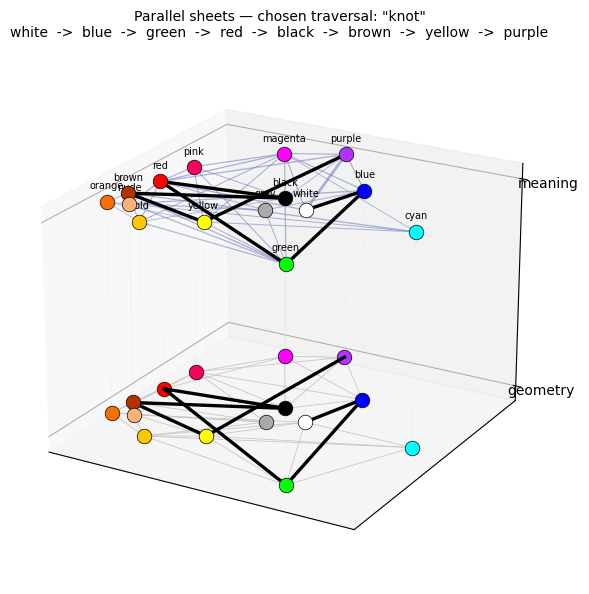

In [12]:
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

CHOSEN_TRAVERSAL = "knot"   # <- any key in LIBRARY

pos={c:(bloch[idx[c]][0],bloch[idx[c]][1]) for c in df["color"]}
for n,c in enumerate(["white","black","grey"]):
    a=n*2*math.pi/3; pos[c]=(0.13*math.cos(a),0.13*math.sin(a))

def draw_multiplex(chosen_name, elev=22, azim=-60):
    chosen=LIBRARY[chosen_name]
    fig=plt.figure(figsize=(9,7)); ax=fig.add_subplot(111,projection="3d")
    zA,zB=0.0,1.0
    for a,b in SHEET_A.edges():
        ax.plot([pos[a][0],pos[b][0]],[pos[a][1],pos[b][1]],[zA,zA],color="#c7c7c7",lw=.6)
    for a,b,d in SHEET_B.edges(data=True):
        ax.plot([pos[a][0],pos[b][0]],[pos[a][1],pos[b][1]],[zB,zB],color="#7a86c0",lw=.4+1.6*d["weight"],alpha=.6)
    for c in df["color"]:
        for z in (zA,zB):
            ax.scatter(*pos[c],z,color=hexcol[c],s=110,edgecolor="k",lw=.5,depthshade=False)
        ax.plot([pos[c][0]]*2,[pos[c][1]]*2,[zA,zB],color="#dedede",lw=.3,ls=":")
        ax.text(pos[c][0],pos[c][1],zB+0.06,c,fontsize=7,ha="center")
    for a,b in zip(chosen[:-1],chosen[1:]):
        for z in (zA,zB):
            ax.plot([pos[a][0],pos[b][0]],[pos[a][1],pos[b][1]],[z,z],color="k",lw=2.4,zorder=6)
    ax.set_title(f'Parallel sheets — chosen traversal: "{chosen_name}"\n{"  ->  ".join(chosen)}',fontsize=10)
    ax.set_zticks([0,1]); ax.set_zticklabels(["geometry","meaning"])
    ax.set_xticks([]); ax.set_yticks([]); ax.view_init(elev=elev,azim=azim)
    plt.tight_layout(); plt.show()

draw_multiplex(CHOSEN_TRAVERSAL)

## 6 · SLERP layering + analyse a chosen traversal and any input colour sequence

SLERP geodesic layering (unchanged). For any sequence we report its geometry cost (total geodesic
length, Sheet A), its meaning cost (total meaning distance, Sheet B), the **named sequences each
transition belongs to**, and the named sequences the whole thing most resembles — that is how the
LLM will be able to refer to sequences.

In [15]:
def slerp(v0,v1,t):
    v0,v1=v0/np.linalg.norm(v0),v1/np.linalg.norm(v1)
    om=np.arccos(np.clip(np.dot(v0,v1),-1,1))
    return v0 if om<1e-6 else (np.sin((1-t)*om)*v0+np.sin(t*om)*v1)/np.sin(om)
def bloch_to_rgb(vec,sat=1.0):
    x,y,z=vec; L=(z+1)/2; hue=(np.degrees(np.arctan2(y,x))-180)%360
    r,g,b=colorsys.hsv_to_rgb(hue/360,sat,min(1.0,0.5+L/2)); return "#%02x%02x%02x"%(int(r*255),int(g*255),int(b*255))
def gradient_of(cols,steps=6):
    g=[]
    for a,b in zip(cols[:-1],cols[1:]):
        if a==b: continue
        va,vb=bloch[idx[a]],bloch[idx[b]]; sa,sb=df["saturation"][idx[a]],df["saturation"][idx[b]]
        for s in range(steps):
            t=s/(steps-1); g.append(bloch_to_rgb(slerp(va,vb,t),(1-t)*sa+t*sb))
    return g

def coerce_sequence(seq):
    if isinstance(seq,str) and seq in LIBRARY: return LIBRARY[seq]
    if isinstance(seq,str): return parse_colors(seq)[0]
    return [ALIASES.get(c.lower(),c.lower()) for c in seq if ALIASES.get(c.lower(),c.lower()) in PALETTE]

def analyse(seq):
    cols=coerce_sequence(seq)
    steps=[(a,b) for a,b in zip(cols[:-1],cols[1:]) if a!=b]
    geoL=sum(angular(bloch[idx[a]],bloch[idx[b]]) for a,b in steps)
    meanL=sum(meaning_distance(a,b) for a,b in steps)
    per_step=[(a,b,seqs_for_transition(a,b)) for a,b in steps]
    return dict(cols=cols,geoL=geoL,meanL=meanL,per_step=per_step,
                nearest=nearest_sequences(cols),gradient=gradient_of(cols))

INPUT_SEQUENCE = "pink, grey, nude, orange"    # <- any colours, or a LIBRARY key
a_chosen=analyse(CHOSEN_TRAVERSAL); a_input=analyse(INPUT_SEQUENCE)
print(f'CHOSEN  "{CHOSEN_TRAVERSAL}": {a_chosen["cols"]}')
print(f'  geometry cost {a_chosen["geoL"]:.2f} rad | meaning cost {a_chosen["meanL"]:.2f}')
for a,b,s in a_chosen["per_step"]:
    print(f'    {a}->{b}: sequences using this move = {s or "(none in library)"}')
print(f'INPUT   "{INPUT_SEQUENCE}": {a_input["cols"]}  most resembles {a_input["nearest"]}')

CHOSEN  "knot": ['white', 'blue', 'green', 'red', 'black', 'brown', 'yellow', 'purple']
  geometry cost 12.98 rad | meaning cost 5.32
    white->blue: sequences using this move = ['knot']
    blue->green: sequences using this move = ['it to self', 'knot', 'toussaint louverture']
    green->red: sequences using this move = ['knot', 'sad to abundant', 'toussaint louverture']
    red->black: sequences using this move = ['knot', 'strict to neutral', 'toussaint louverture']
    black->brown: sequences using this move = ['knot']
    brown->yellow: sequences using this move = ['cocky to observant', 'knot']
    yellow->purple: sequences using this move = ['knot', 'stuck to escape']
INPUT   "pink, grey, nude, orange": ['pink', 'grey', 'nude', 'orange']  most resembles [(0.8, 'plot'), (0.5, 'distrust to thoughtful'), (0.4, 'productive to messy')]


## 7 · The LLM comments on the chosen traversal, considering your input sequence

The evidence gives the model both sequences, each atom's semantic-atom class and JSON meaning, the
two-sheet numbers, and — crucially — **the named sequences each transition belongs to** so it can
refer to them. Every meaning must come from `la_matrice_words.json`; every emotion from the class;
sequence names may only be those listed in the evidence.

short in geometry, short in meaning — a gentle, coherent move (colours near in space and in meaning);
short in geometry, long in meaning — colours that look/sit alike but mean very different things (a quiet visual step that's actually a big conceptual jump);
long in geometry, short in meaning — colours far apart on the sphere whose meanings nonetheless rhyme (a bold visual leap that still makes sense);
long in both — a genuine rupture.

In [16]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.llms import Ollama
from langchain_core.runnables import RunnableLambda
llm = Ollama(model="llama3:8b")

def atoms_block(cols, title):
    seen=[]; out=[title]
    for c in cols:
        if c in seen: out.append(f'  [{c}] (return)'); continue
        seen.append(c); i=idx[c]; meaning,src=atom_meaning(i)
        out += [f'  [{c}] class = {df["stage"][i]}-stage atom  (+{df["emotion_pos"][i]} / -{df["emotion_neg"][i]})',
                f'        meaning [{src}]: {meaning}',
                f'        appears in sequences: {sorted(COLOR2SEQ[c]) or "(none)"}']
    return out

def steps_block(per_step, title):
    out=[title]
    for a,b,s in per_step:
        out.append(f'  {a} -> {b}   belongs to sequences: {s or "(none in library)"}')
    return out

def build_evidence(inputs):
    ch=analyse(inputs["chosen"]); inp=analyse(inputs["input_sequence"])
    L=[f'CHOSEN TRAVERSAL: "{inputs["chosen"]}"  =  {" -> ".join(ch["cols"])}',
       f'  geometry cost = {ch["geoL"]:.2f} rad (Sheet A) ; meaning cost = {ch["meanL"]:.2f} (Sheet B)',
       ""]
    L+=atoms_block(ch["cols"],"CHOSEN — semantic-atom classes + JSON meanings:")
    L+=[""]+steps_block(ch["per_step"],"CHOSEN — each move and the named sequences it belongs to:")
    L+=["",
        f'INPUT COLOUR SEQUENCE: {" -> ".join(inp["cols"])}',
        f'  geometry cost = {inp["geoL"]:.2f} rad ; meaning cost = {inp["meanL"]:.2f}',
        f'  most resembles named sequences: {inp["nearest"]}',
        ""]
    L+=atoms_block(inp["cols"],"INPUT — semantic-atom classes + JSON meanings:")
    L+=[""]+steps_block(inp["per_step"],"INPUT — each move and the named sequences it belongs to:")
    L+=["",
        f'TWO-SHEET COMPARISON (whole palette): Spearman(geometry, meaning) = '
        f'{("n/a" if not np.isfinite(rho) else format(rho,"+.3f"))} -> {AGREE}',
        f'SLERP gradient of chosen: {" ".join(ch["gradient"])}']
    return {**inputs,"evidence":"\n".join(L)}

evidence_step=RunnableLambda(build_evidence)

prompt=ChatPromptTemplate.from_messages([
 ("system","""
You write poetic but grounded advice based in morphology.

Style:
- lyrical but geometrically and architecturally precise
- computational
- relational through rotations
- non-extractive
- shift orientation from focus on the vertical, like a column, or growth to block, like a wall.
  These allow for the image to be objectified and personified for private use.
- refocus on grounding in truth with the horizontal, a beam, a link and support, also a reference
  to light and moving forward.
"""),
 ("human","""
Two colour sequences have ALREADY been computed on the Bloch sphere and compared across two parallel
sheets: SHEET A = geometry (from the Bloch sphere), SHEET B = meaning (from la_matrice_words.json).
Do NOT compute or invent geometry, weights, colours, paths, meanings, or sequence names. Use ONLY the
"meaning [...]" lines for meaning, the "semantic-atom class" lines for feeling, and only the sequence
names that appear in the evidence.

Write smooth, diplomatic, navigational advice that:
1. reads the CHOSEN traversal as the primary journey, in order, naming each colour by its stage class
   and leaning on that atom's JSON meaning-words for the counsel at that step; treat a "(return)" as
   coming back to a place already visited, changed;
2. REFERS TO SEQUENCES BY NAME: for each move, name the sequences it belongs to (from the evidence)
   -- e.g. "this red->purple move is the turn you also make in 'lost to open' and 'happy to resistant'"
   -- so the advice is woven from your own vocabulary of traversals;
3. uses the geometry cost and the meaning cost to say where the journey is a smooth step versus a
   leap in space, versus a near or far step in meaning;
4. then CONSIDERS the INPUT colour sequence: where it meets or diverges from the chosen traversal, and
   which named sequences it most resembles -- speak as if the input is where they are now and the
   chosen traversal is the path being offered;
5. closes on the two-sheet finding (whether meaning tracks geometry or is organised independently) as
   a note on trusting meaning over mere proximity.

EVIDENCE:
{evidence}
""")
])

chain = evidence_step | prompt | llm

In [17]:
chain.invoke({"chosen": CHOSEN_TRAVERSAL, "input_sequence": INPUT_SEQUENCE})

'Dear traveler, I see you\'ve arrived at the crossroads, with the chosen traversal of "knot" before you. This path has already unfolded its geometry and meaning, a harmonious blend of 12.98 rad and 5.32, respectively.\n\nAs you embark on this journey, I\'ll guide you through the stages, using the meaning-words from the la_matrice_words.json to offer counsel. Remember, the sequence names will be woven into our conversation, as we navigate the knots of your journey.\n\nThe first move, from white to blue, belongs to the sequence "knot." This is a smooth step, a gentle turning point, as you transition from action to novelty. The meaning-words "resonance" echo through this stage, reminding you to tune into your inner frequency.\n\nThe next move, blue to green, belongs to sequences like "it to self" and "knot." This leap in space requires a deeper exploration of your creative potential. The meaning-words "creative" invite you to tap into your imagination, allowing your ideas to flow like a g

### Notes for a reviewer

* **Two genuinely different graphs over the same nodes.** Sheet A is fixed by the semantic-atom
  geometry (the Bloch sphere); Sheet B is fixed by your JSON meanings. The Spearman number reports
  whether meaning tracks geometry — if it sits near zero, that is evidence your meanings carry
  structure the colour geometry alone does not.
* **Sequences are a named vocabulary, not a sheet.** Every transition is tagged with the named
  traversals that contain it, and every input is placed against the library by resemblance, so the
  LLM's commentary can cite your own sequences.
* **The LLM is downstream of all of this** — it interprets computed evidence, cites `la_matrice_words.json`
  meanings, the Surov classes, and only the sequence names present in the evidence, so its output is
  auditable.
* **Knobs to report:** `k` for each sheet, the SLERP `steps`, whether `la_matrice_words.json` or the
  sheet fallback supplied meanings, and `MEANING_METHOD` (embeddings vs lexical). The accurate RGB-cube
  atom map (Surov Eqs. 17–18, p. 11) is a drop-in refinement for Sheet A if perceptual exactness is
  questioned.
